# Fase II — Construcción del Modelo Nulo mediante Simulación Monte Carlo

## Objetivo

Una vez construido el modelo geométrico espacial del complejo de Giza, el siguiente paso consiste en determinar si la configuración observada puede ser explicada razonablemente por procesos aleatorios.

La hipótesis central de esta fase es:

\[
H_0:
\text{La disposición espacial observada puede surgir por azar}
\]

frente a:

\[
H_1:
\text{La disposición espacial observada presenta estructura espacial significativa}
\]

Para evaluar esta hipótesis se construirá una distribución nula mediante simulación Monte Carlo.

La idea fundamental consiste en generar miles de configuraciones espaciales aleatorias dentro del mismo dominio geográfico ocupado por el complejo de Giza y comparar dichas configuraciones con la geometría observada.

Este procedimiento permitirá estimar la probabilidad de obtener una configuración similar a la observada bajo condiciones puramente aleatorias.

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform



master = pd.read_csv("../data/complete_data_points.csv")

master.head()

,name,representation,type,x,y
0,KHUFU,Earth,Pyramid,319996.452554,3.317938e+06
1,KHAFRE,Venus,Pyramid,319654.869416,3.317590e+06
2,MENKAURE,Mars,Pyramid,319409.733737,3.317210e+06
3,SPHINX,Venus,Monument,320311.439909,3.317506e+06
4,TEMPLE_CENTER,Mercury,Temple,319824.278577,3.317588e+06


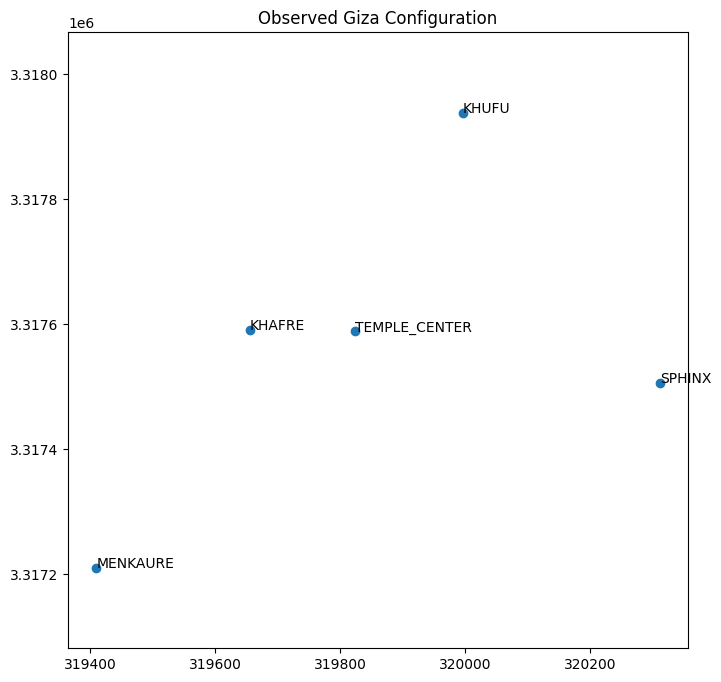

In [46]:
plt.figure(figsize=(8,8))

plt.scatter(master["x"],master["y"])

for _,row in master.iterrows():
    plt.text(
        row["x"],
        row["y"],
        row["name"]
    )

plt.axis("equal")
plt.title("Observed Giza Configuration")

plt.show()

In [47]:
xmin = master["x"].min()
xmax = master["x"].max()

ymin = master["y"].min()
ymax = master["y"].max()

print("xmin =",xmin)
print("xmax =",xmax)

print("ymin =",ymin)
print("ymax =",ymax)

xmin = 319409.73373705
xmax = 320311.4399093158
ymin = 3317210.39235008
ymax = 3317938.40967688


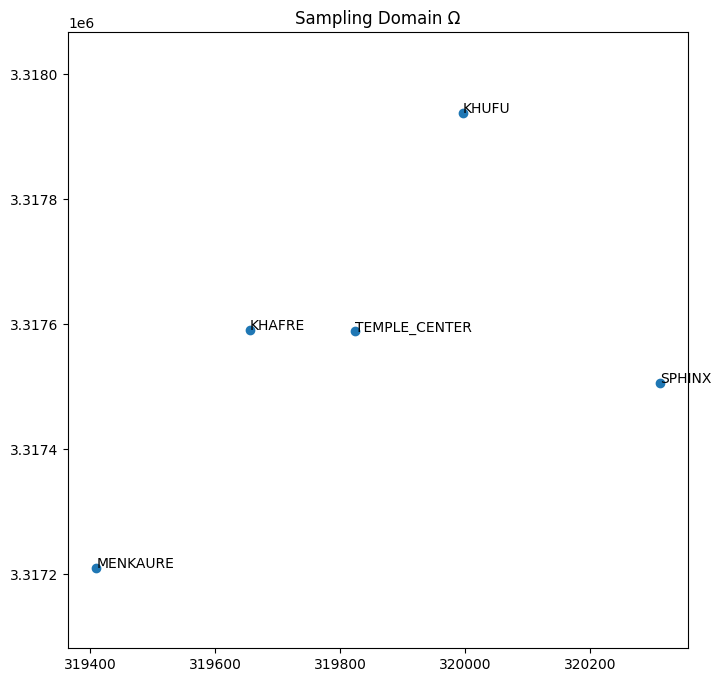

In [48]:
plt.figure(figsize=(8,8))

plt.scatter(master["x"],master["y"])

for _,row in master.iterrows():
    plt.text(
        row["x"],
        row["y"],
        row["name"]
    )

plt.xlim(xmin-50,xmax+50)
plt.ylim(ymin-50,ymax+50)

plt.axis("equal")
plt.title("Sampling Domain Ω")

plt.show()

In [49]:
gx = master["x"].mean()
gy = master["y"].mean()

print(gx)
print(gy)

319839.3548386748
3317566.673433858


In [50]:
master["r"] = np.sqrt(
    (master["x"]-gx)**2
    +
    (master["y"]-gy)**2
)

master

,name,representation,type,x,y,r
0,KHUFU,Earth,Pyramid,319996.452554,3.317938e+06,403.568491
1,KHAFRE,Venus,Pyramid,319654.869416,3.317590e+06,185.994809
2,MENKAURE,Mars,Pyramid,319409.733737,3.317210e+06,558.131258
3,SPHINX,Venus,Monument,320311.439909,3.317506e+06,475.993913
4,TEMPLE_CENTER,Mercury,Temple,319824.278577,3.317588e+06,26.483565


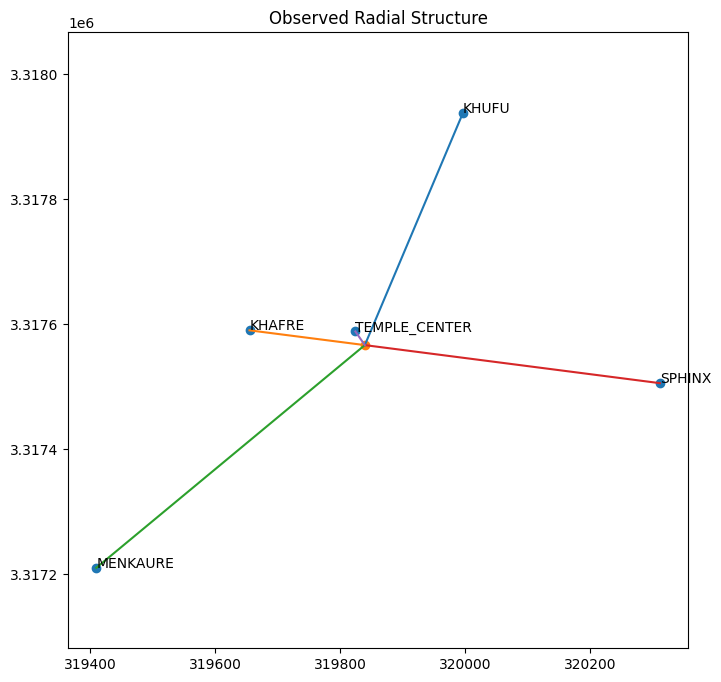

In [51]:
plt.figure(figsize=(8,8))

plt.scatter(master["x"],master["y"])

plt.scatter(gx,gy)

for _,row in master.iterrows():
    
    plt.plot(
        [gx,row["x"]],
        [gy,row["y"]]
    )

    plt.text(
        row["x"],
        row["y"],
        row["name"]
    )

plt.axis("equal")
plt.title("Observed Radial Structure")

plt.show()

In [52]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

coords_obs = master[["x","y"]].values

D_obs = squareform(
    pdist(coords_obs)
)

D_obs

array([[  0.        , 487.69345478, 935.01240545, 535.13588366,
        390.02281487],
       [487.69345478,   0.        , 452.14724227, 661.98868349,
        169.4195235 ],
       [935.01240545, 452.14724227,   0.        , 948.86151047,
        561.04607345],
       [535.13588366, 661.98868349, 948.86151047,   0.        ,
        494.1225658 ],
       [390.02281487, 169.4195235 , 561.04607345, 494.1225658 ,
          0.        ]])

In [53]:
observed_r = np.sort(
    master["r"].values
)

observed_r

array([ 26.48356512, 185.99480908, 403.56849053, 475.99391291,
       558.13125841])

In [54]:
TD_obs = 0

In [55]:
def simulate_configuration():
    
    xs = np.random.uniform(
        xmin,
        xmax,
        len(master)
    )

    ys = np.random.uniform(
        ymin,
        ymax,
        len(master)
    )

    gx_sim = np.mean(xs)
    gy_sim = np.mean(ys)

    r_sim = np.sqrt(
        (xs-gx_sim)**2
        +
        (ys-gy_sim)**2
    )

    return np.sort(r_sim)

In [56]:
def compute_T(r_sim):

    return np.sum(
        (r_sim-observed_r)**2
    )

In [57]:
r_test = simulate_configuration()

T_test = compute_T(r_test)

print(T_test)

62836.81653879665


In [58]:
N = 10000

T_values = []

for _ in range(N):

    r_sim = simulate_configuration()

    T_values.append(
        compute_T(r_sim)
    )

T_values = np.array(T_values)

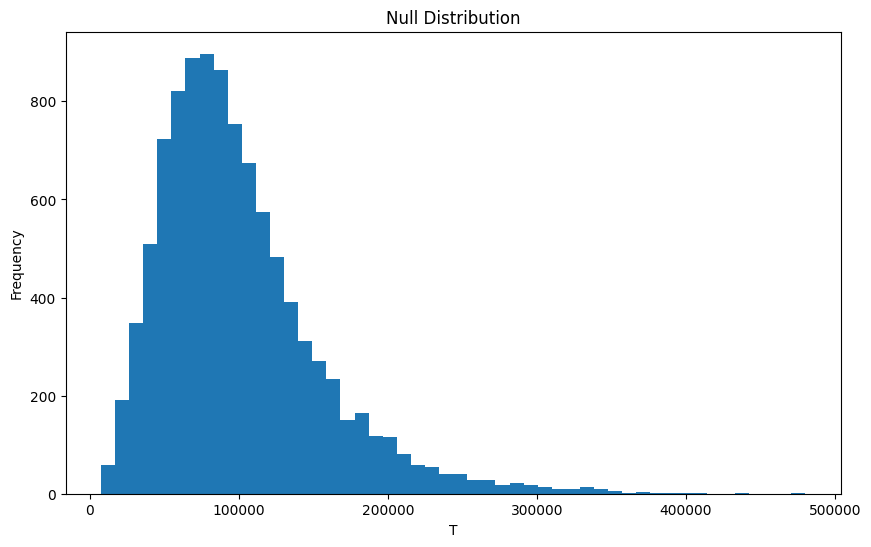

In [59]:
plt.figure(figsize=(10,6))

plt.hist(
    T_values,
    bins=50
)

plt.xlabel("T")
plt.ylabel("Frequency")

plt.title(
    "Null Distribution"
)

plt.show()

In [60]:
T_obs = 0

p_value = np.mean(
    T_values <= T_obs
)

print(
    "p-value =",
    p_value
)

p-value = 0.0


# Fase 2.2

In [61]:
observed_r = np.sort(master["r"].values)

In [62]:
observed_ratios = observed_r[1:] / observed_r[:-1]

observed_ratios

array([7.02302761, 2.16978362, 1.17946253, 1.17255966])

In [63]:
def compute_TR(r_sim):

    r_sim = np.sort(r_sim)

    ratios_sim = r_sim[1:] / r_sim[:-1]

    return np.sum(
        (ratios_sim-observed_ratios)**2
    )

In [64]:
TR_values = []

for _ in range(10000):

    r_sim = simulate_configuration()

    TR_values.append(
        compute_TR(r_sim)
    )

TR_values = np.array(TR_values)

In [65]:
master["theta"] = np.arctan2(
    master["y"]-gy,
    master["x"]-gx
)

In [66]:
observed_theta = np.sort(
    master["theta"].values
)

In [67]:
observed_dtheta = np.diff(
    observed_theta
)

In [68]:
def angular_structure(xs,ys):

    gx = np.mean(xs)
    gy = np.mean(ys)

    theta = np.arctan2(
        ys-gy,
        xs-gx
    )

    theta = np.sort(theta)

    return np.diff(theta)

In [69]:
def compute_TA(xs,ys):

    dtheta_sim = angular_structure(xs,ys)

    return np.sum(
        (dtheta_sim-observed_dtheta)**2
    )

In [70]:
TA_values = []

for _ in range(10000):

    xs = np.random.uniform(
        xmin,
        xmax,
        len(master)
    )

    ys = np.random.uniform(
        ymin,
        ymax,
        len(master)
    )

    TA_values.append(
        compute_TA(xs,ys)
    )

In [71]:
coords_obs = master[["x","y"]].values

D_obs = squareform(
    pdist(coords_obs)
)

In [72]:
def distance_matrix(xs,ys):

    coords = np.column_stack(
        [xs,ys]
    )

    return squareform(
        pdist(coords)
    )

In [73]:
def compute_TD(xs,ys):

    D_sim = distance_matrix(xs,ys)

    return np.linalg.norm(
        D_sim-D_obs
    )

In [74]:
TD_values = []

for _ in range(10000):

    xs = np.random.uniform(
        xmin,
        xmax,
        len(master)
    )

    ys = np.random.uniform(
        ymin,
        ymax,
        len(master)
    )

    TD_values.append(
        compute_TD(xs,ys)
    )

In [75]:
epsilon = 0.15

r_min = observed_r*(1-epsilon)
r_max = observed_r*(1+epsilon)

In [76]:
def orbital_score(r_sim):

    hits = 0

    r_sim = np.sort(r_sim)

    for r,a,b in zip(
        r_sim,
        r_min,
        r_max
    ):

        if a <= r <= b:

            hits += 1

    return hits

In [77]:
scores = []

for _ in range(10000):

    r_sim = simulate_configuration()

    scores.append(
        orbital_score(r_sim)
    )

In [78]:
r = np.random.uniform(
    r_min,
    r_max
)

theta = np.random.uniform(
    0,
    2*np.pi
)

In [79]:
x = gx + r*np.cos(theta)

y = gy + r*np.sin(theta)

In [80]:
def summarize_distribution(values, name):

    print("="*50)
    print(name)
    print("="*50)

    print(f"N simulations : {len(values)}")
    print(f"Mean          : {np.mean(values):.4f}")
    print(f"Median        : {np.median(values):.4f}")
    print(f"Std           : {np.std(values):.4f}")
    print(f"Min           : {np.min(values):.4f}")
    print(f"Max           : {np.max(values):.4f}")

    print("\nPercentiles")

    for p in [1,5,25,50,75,95,99]:

        print(
            f"P{p}: {np.percentile(values,p):.4f}"
        )

In [81]:
summarize_distribution(TR_values,"Radial Ratio Test")

Radial Ratio Test
N simulations : 10000
Mean          : 40.0246
Median        : 32.2834
Std           : 615.4581
Min           : 0.0853
Max           : 49209.4383

Percentiles
P1: 1.7727
P5: 9.2555
P25: 26.0812
P50: 32.2834
P75: 35.3667
P95: 37.1641
P99: 38.9180


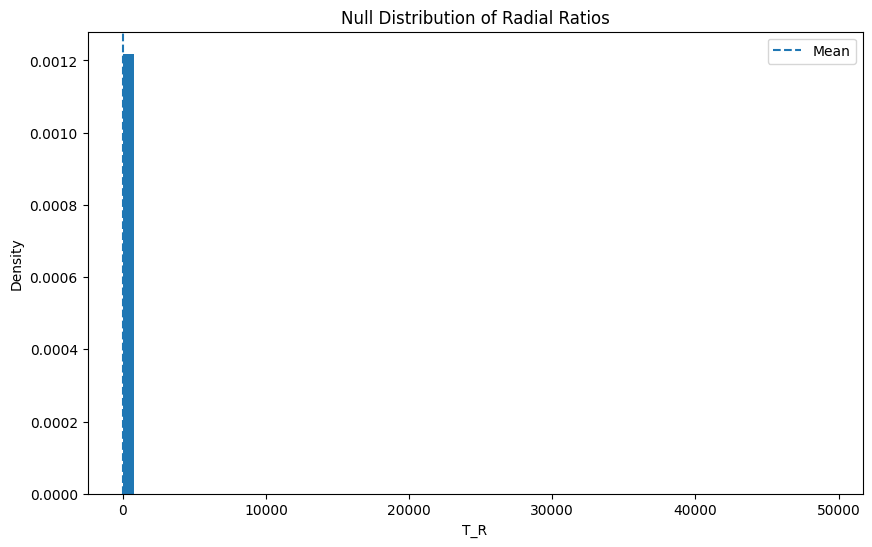

In [82]:
plt.figure(figsize=(10,6))

plt.hist(
    TR_values,
    bins=60,
    density=True
)

plt.axvline(
    np.mean(TR_values),
    linestyle="--",
    label="Mean"
)

plt.xlabel("T_R")
plt.ylabel("Density")

plt.title(
    "Null Distribution of Radial Ratios"
)

plt.legend()

plt.show()

NameError: name 'TR_obs' is not defined

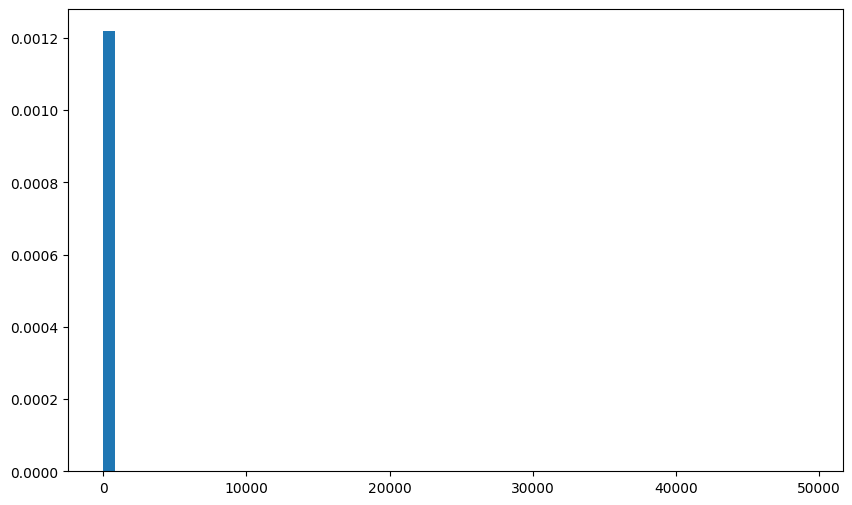

In [83]:
plt.figure(figsize=(10,6))

plt.hist(
    TR_values,
    bins=60,
    density=True
)

plt.axvline(
    TR_obs,
    linewidth=3,
    label="Observed"
)

plt.legend()

plt.xlabel("T_R")

plt.title(
    "Observed Statistic vs Null Distribution"
)

plt.show()

In [ ]:
percentile = (
    np.sum(TR_values <= TR_obs)
    /
    len(TR_values)
)*100

print(percentile)

NameError: name 'TR_obs' is not defined

In [ ]:
r = np.sum(
    TR_values <= TR_obs
)

N = len(TR_values)

p_value = (r+1)/(N+1)

print(p_value)

In [ ]:
from scipy import stats

stats.probplot(
    TR_values,
    dist="norm",
    plot=plt
)

plt.title(
    "QQ Plot"
)

plt.show()

In [ ]:
running_mean = np.cumsum(TR_values)

running_mean = (
    running_mean
    /
    np.arange(
        1,
        len(TR_values)+1
    )
)

plt.figure(figsize=(10,6))

plt.plot(running_mean)

plt.xlabel("Simulation")

plt.ylabel("Running Mean")

plt.title(
    "Monte Carlo Convergence"
)

plt.show()

In [ ]:
all_x = []
all_y = []

for _ in range(10000):

    xs = np.random.uniform(
        xmin,
        xmax,
        len(master)
    )

    ys = np.random.uniform(
        ymin,
        ymax,
        len(master)
    )

    all_x.extend(xs)
    all_y.extend(ys)

In [ ]:
plt.figure(figsize=(8,8))

plt.hexbin(
    all_x,
    all_y,
    gridsize=50
)

plt.colorbar()

plt.title(
    "Monte Carlo Spatial Density"
)

plt.show()

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,8))

sns.heatmap(
    D_obs,
    annot=True
)

plt.title(
    "Observed Distance Matrix"
)

plt.show()